In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd

In [20]:
# Import useful data
df = pd.read_parquet('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/code/calculated_magnitudes.parquet')
gi_listP = df['giP'].tolist()
gr_listP = df['grP'].tolist()
CaHKg_listP = df['CaHKgP'].tolist()

feh_list = df['feh'].tolist()
logg_list = df['logg'].tolist()
alpha_list = df['alpha'].tolist()
teff_list = df['teff'].tolist()

feh = np.array(feh_list)
logg = np.array(logg_list)
alpha = np.array(alpha_list)
teff = np.array(teff_list)

/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_33213/425735096.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


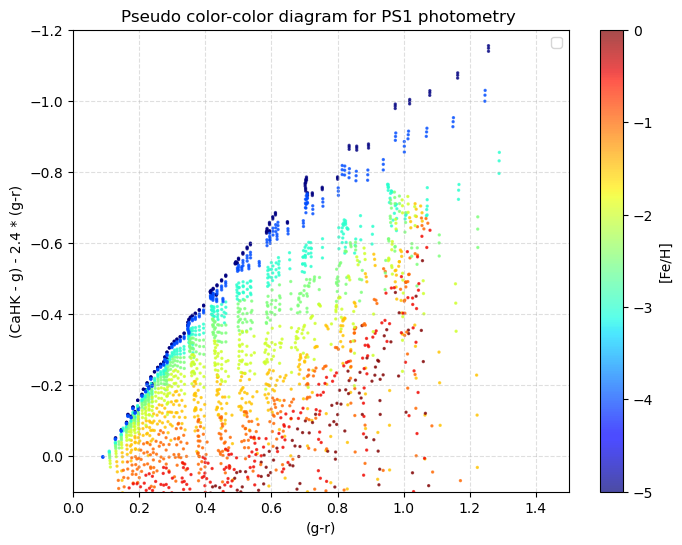

In [21]:
# Define numpy array
gi = np.array(gi_listP)
gr = np.array(gr_listP)
CaHKg = np.array(CaHKg_listP)

# Calculate x and y axis
bf = 2.4
x_axis = gr
y_axis = np.array(CaHKg_listP-bf*gr)
xlabel = f'(g-r)'
ylabel = f'(CaHK - g) - {bf} * (g-r)'

# Plot the pseudo color-color diagram for PS1

plt.figure(figsize=(8,6))
sc = plt.scatter(x_axis,y_axis, c=feh_list, cmap='jet', s=2, alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(f'Pseudo color-color diagram for PS1 photometry ')
plt.colorbar(label='[Fe/H]')

plt.xlim(0,1.5)
plt.ylim(0.1,-1.2)
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend()
plt.show()

In [45]:
# Define masks
mask_RGB = (teff < 5700) & (logg < 2) 
mask_alpha = (alpha == 0.4)
final_mask = mask_RGB & mask_alpha

# Mask the data
x_plot = x_axis[final_mask] 
y_plot = y_axis[final_mask]
c_plot = feh[final_mask] 

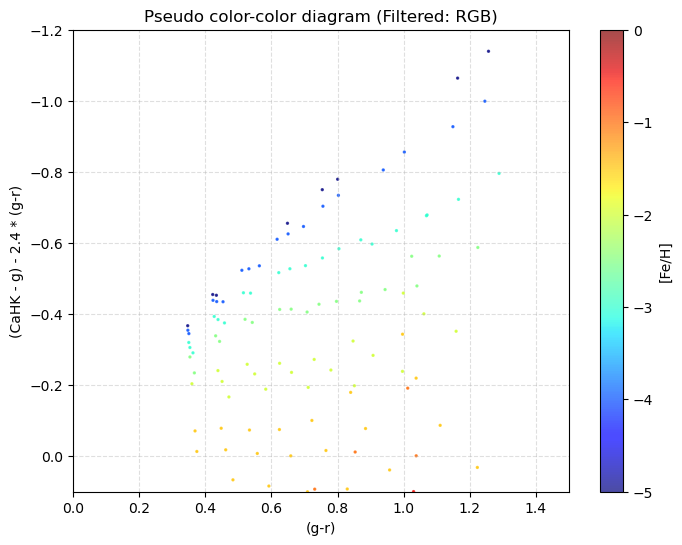

In [46]:
# Plot masked data
plt.figure(figsize=(8,6))

# Plot masked data
sc = plt.scatter(x_plot, y_plot, c=c_plot, cmap='jet', s=2, alpha=0.7)

plt.gca().invert_yaxis()
plt.xlabel(f'(g-r)')
plt.ylabel(f'(CaHK - g) - {bf} * (g-r)')
plt.title(f'Pseudo color-color diagram (Filtered: RGB)')
plt.colorbar(sc, label='[Fe/H]') # Pass the scatter object 'sc' to colorbar

plt.xlim(0, 1.5)
plt.ylim(0.1, -1.2)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

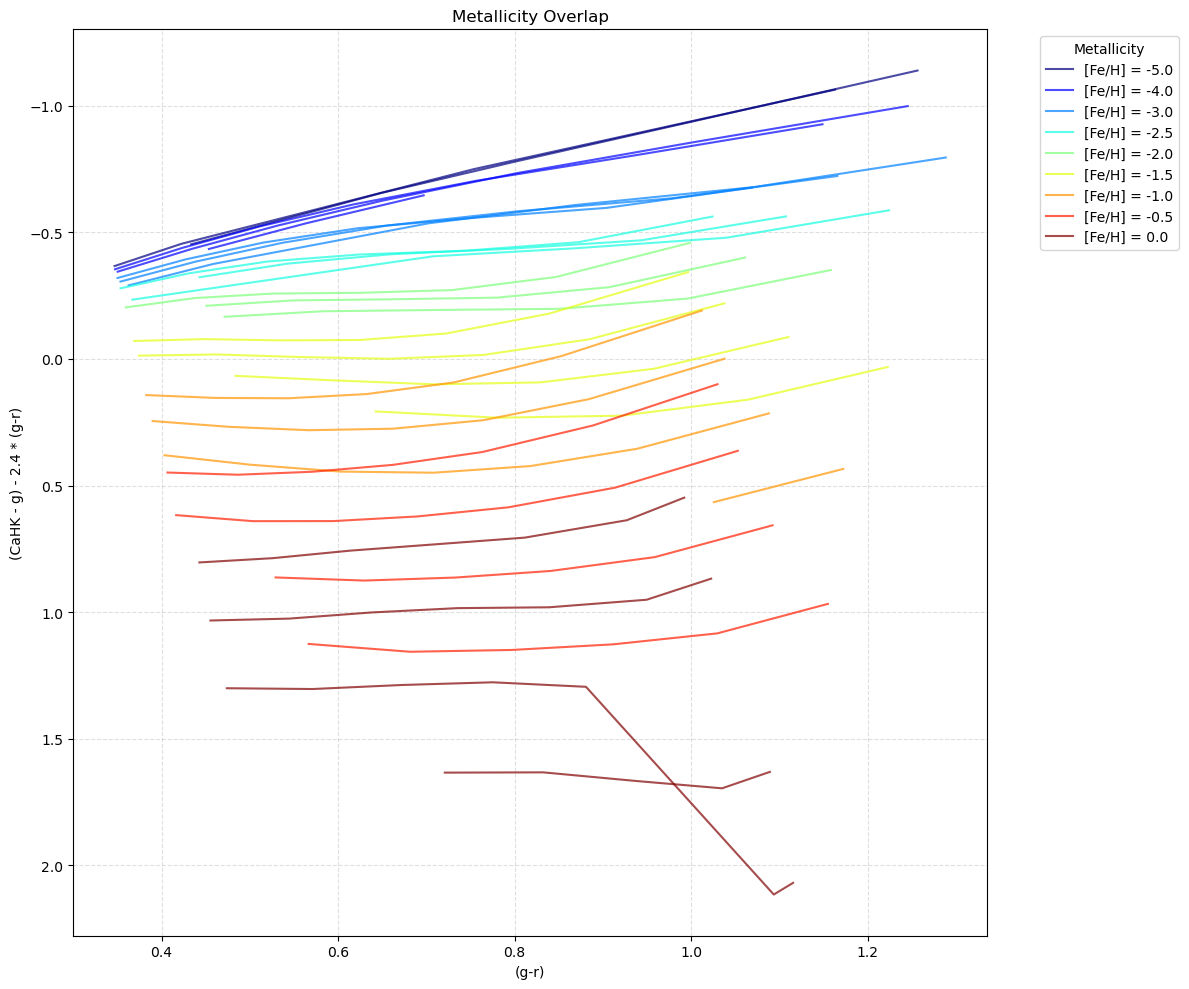

In [47]:
# Plot values with one color per metallicity and one line per log g to see the overlap
plt.figure(figsize=(12, 10))

# Get all unique values
unique_feh = np.unique(feh[final_mask])
unique_logg = np.unique(logg[final_mask])

selected_feh = np.unique(np.round(unique_feh, 1)) 

# Create a color map
colors = cm.jet(np.linspace(0, 1, len(selected_feh)))

# Loop over metallicities 
for i, feh_val in enumerate(selected_feh):

    
    label_added = False # To ensure only one legend entry per Fe/H value
    
    for lg in unique_logg:
        # Create a mask to group by metallicity and log g
        mask_iso = (np.isclose(feh, feh_val, atol=0.01)) & (np.isclose(logg, lg, atol=0.01))
        mask_final_iso = final_mask & mask_iso
        
        x_iso = x_axis[mask_final_iso]
        y_iso = y_axis[mask_final_iso]
        
        if len(x_iso) > 1: 
            sort_inds = np.argsort(x_iso)
            
            lbl = f'[Fe/H] = {feh_val:.1f}' if not label_added else ""
            
            plt.plot(x_iso[sort_inds], y_iso[sort_inds], 
                     color=colors[i], 
                     linewidth=1.5, 
                     alpha=0.7,
                     label=lbl)
            
            label_added = True

plt.gca().invert_yaxis()
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title('Metallicity Overlap')
plt.legend(title="Metallicity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:56: SyntaxWarning: invalid escape sequence '\l'
/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_33213/1971504911.py:56: SyntaxWarning: invalid escape sequence '\l'
  current_ax.set_title(f'Separability at $\log g = {lg:.1f}$')


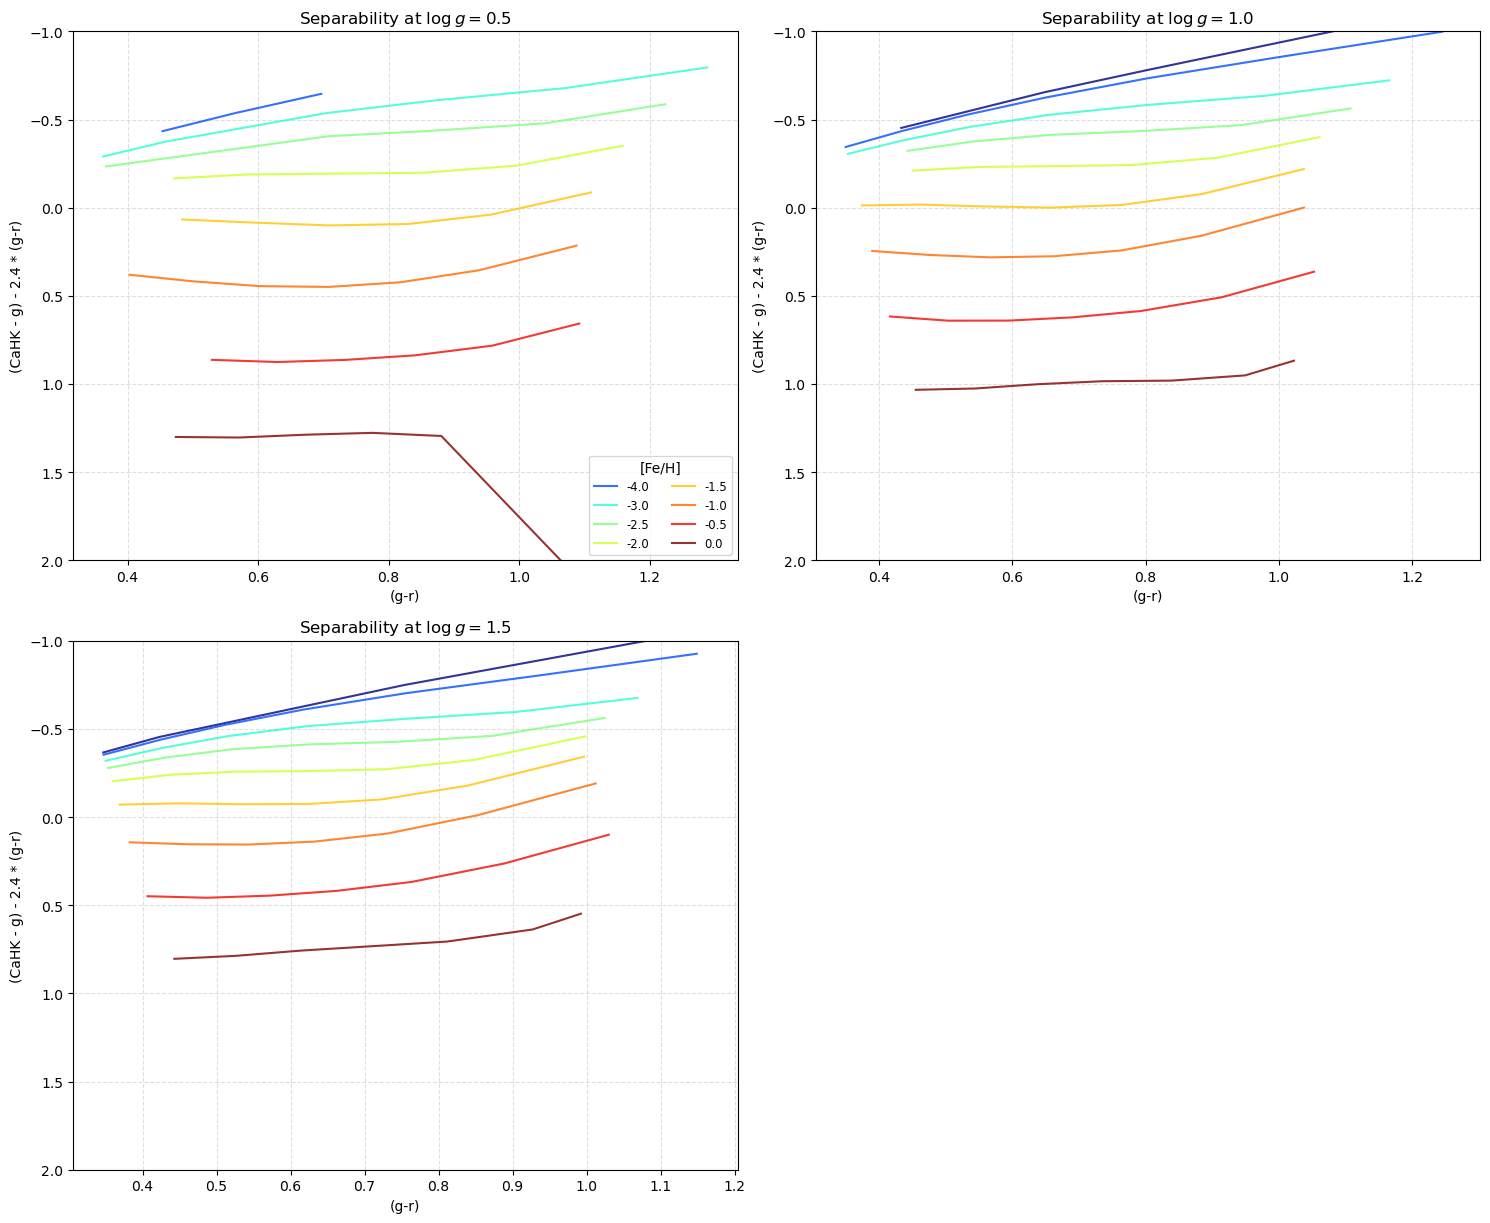

In [48]:
# Plot metallicities lines for each log g to see the separability
unique_logg = np.unique(logg[final_mask])
unique_logg_sorted = np.sort(unique_logg)

# Remove log g = 0 
unique_logg_sorted = unique_logg_sorted[unique_logg_sorted > 0.1]

# Define the specific metallicities to test
unique_feh = np.unique(np.round(feh[final_mask], 1))
target_fehs = unique_feh 

# Setup colormap
norm = mcolors.Normalize(vmin=min(target_fehs), vmax=max(target_fehs))
cmap = plt.get_cmap('jet')

num_plots = len(unique_logg_sorted)
cols = 2
rows = (num_plots + 1) // cols
if num_plots % cols != 0:
    rows += 1

fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))

if num_plots == 1:
    axes_flat = [axes]
else:
    axes_flat = axes.flat

# Iterate through each Log g (skipping 0.0)
for i, lg in enumerate(unique_logg_sorted):
    current_ax = axes_flat[i]
    
    # Iterate through each metallicity to draw the lines
    for feh_val in target_fehs:
        
        # Create mask: Specific Log g and Specific Fe/H
        mask = (np.isclose(logg, lg, atol=0.01)) & \
               (np.isclose(feh, feh_val, atol=0.01))
        
        final_mask_combined = final_mask & mask
        
        x_iso = x_axis[final_mask_combined]
        y_iso = y_axis[final_mask_combined]
        
        if len(x_iso) > 1:
            sort_inds = np.argsort(x_iso)
            color = cmap(norm(feh_val))
            
            current_ax.plot(x_iso[sort_inds], y_iso[sort_inds], 
                    color=color, 
                    linewidth=1.5, 
                    alpha=0.8,
                    label=f'{feh_val:.1f}') 

    current_ax.invert_yaxis()
    current_ax.set_title(f'Separability at $\log g = {lg:.1f}$')
    current_ax.set_xlabel(xlabel)
    current_ax.set_ylabel(ylabel)
    current_ax.grid(True, linestyle='--', alpha=0.4)
    current_ax.set_ylim(2,-1)
    
    # Add a legend to the first plot only 
    if i == 0:
        current_ax.legend(title="[Fe/H]", loc='lower right', ncol=2, fontsize='small')

# Remove empty subplots if any
total_plots_possible = rows * cols
for j in range(num_plots, total_plots_possible):
    fig.delaxes(axes_flat[j])


plt.tight_layout()
plt.show()

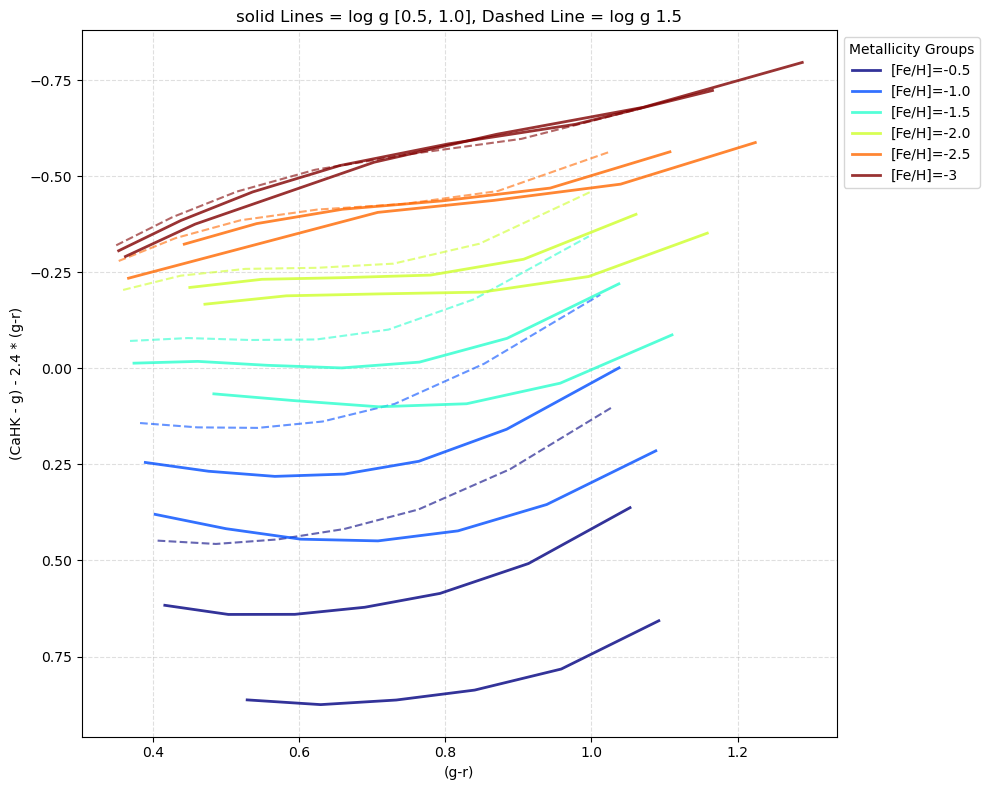

In [49]:
# Plot to see overlap of different log g and if we can group some log g
import matplotlib.cm as cm

# Setup Data
unique_feh = np.unique(np.round(feh[final_mask], 1))

target_fehs = [-0.5,-1.0, -1.5, -2.0, -2.5,-3] 

# Define the group and the outlier
group_logg = [0.5, 1.0] 
outlier_logg = [1.5]   

colors = cm.jet(np.linspace(0, 1, len(target_fehs)))

plt.figure(figsize=(10, 8))

# Loop over metallicity
for i, feh_val in enumerate(target_fehs):
    
    c = colors[i]
    
    for lg in group_logg:
        # Create mask: group by Log g and Fe/H
        mask = (np.isclose(logg, lg, atol=0.01)) & (np.isclose(feh, feh_val, atol=0.01))
        mask_final = final_mask & mask
        
        x_iso = x_axis[mask_final]
        y_iso = y_axis[mask_final]
        
        if len(x_iso) > 1:
            sort_inds = np.argsort(x_iso)
            # Solid line for the group members
            lbl = f'[Fe/H]={feh_val}' if lg == group_logg[0] else ""
            plt.plot(x_iso[sort_inds], y_iso[sort_inds], 
                     color=c, linestyle='-', linewidth=2, alpha=0.8, label=lbl)

    for lg in outlier_logg:
        # define mask 
        mask = (np.isclose(logg, lg, atol=0.01)) & (np.isclose(feh, feh_val, atol=0.01))
        mask_final = final_mask & mask
        
        x_iso = x_axis[mask_final]
        y_iso = y_axis[mask_final]
        
        if len(x_iso) > 1:
            sort_inds = np.argsort(x_iso)
            # Dashed line for the potential outlier
            plt.plot(x_iso[sort_inds], y_iso[sort_inds], 
                     color=c, linestyle='--', linewidth=1.5, alpha=0.6)

plt.gca().invert_yaxis()
plt.title(f'solid Lines = log g [0.5, 1.0], Dashed Line = log g 1.5')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.legend(title="Metallicity Groups", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

In [ ]:
# Create a new Dataframe to store stellar parameters
df_new = pd.DataFrame({
    'metallicity': feh,
    'logg': logg,
    'Teff': teff,
    'alpha': alpha,
    'g_minus_r': gr,
    'g_minus_i': gi,
    'CaHK_minus_g' : CaHKg_listP
})
df_new.head()

,metallicity,logg,Teff,alpha,g_minus_r,g_minus_i,CaHK_minus_g
0,-5.0,3.5,4500.0,0.0,0.701908,1.053413,0.916247
1,-5.0,3.5,4500.0,0.2,0.701959,1.053462,0.920233
2,-5.0,3.5,4500.0,0.4,0.702024,1.053525,0.925201
3,-5.0,4.0,4500.0,0.0,0.703729,1.056751,0.910439
4,-5.0,4.0,4500.0,0.2,0.703783,1.056803,0.914500
